In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import pandas as pd
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/winter-fashoin-trends/Winter_Fashion_Trends_Dataset.csv


In [2]:
df = pd.read_csv("../input/winter-fashoin-trends/Winter_Fashion_Trends_Dataset.csv")

In [3]:
df

,ID,Brand,Category,Color,Material,Style,Gender,Season,Price(USD),Popularity_Score,Customer_Rating,Trend_Status
0,1,Adidas,Gloves,Brown,Polyester,Streetwear,Women,Winter 2025,244.06,6.0,4.9,Trending
1,2,Gucci,Gloves,Red,Leather,Sporty,Men,Winter 2023,366.73,8.8,3.3,Trending
2,3,H&M,Coat,Brown,Fleece,Streetwear,Unisex,Winter 2025,741.55,4.8,3.5,Trending
3,4,North Face,Coat,Blue,Cashmere,Formal,Men,Winter 2024,116.09,7.5,3.1,Outdated
4,5,Mango,Thermal,Blue,Cashmere,Formal,Unisex,Winter 2025,193.16,7.8,4.3,Outdated
...,...,...,...,...,...,...,...,...,...,...,...,...
145,146,Mango,Coat,Green,Down,Casual,Women,Winter 2024,614.06,2.9,4.5,Emerging
146,147,H&M,Jacket,Gray,Polyester,Formal,Unisex,Winter 2023,329.70,3.0,4.4,Outdated
147,148,Uniqlo,Jacket,Gray,Leather,Casual,Unisex,Winter 2024,411.84,9.7,4.7,Outdated
148,149,Prada,Beanie,Black,Wool,Formal,Unisex,Winter 2025,407.11,3.5,3.0,Classic


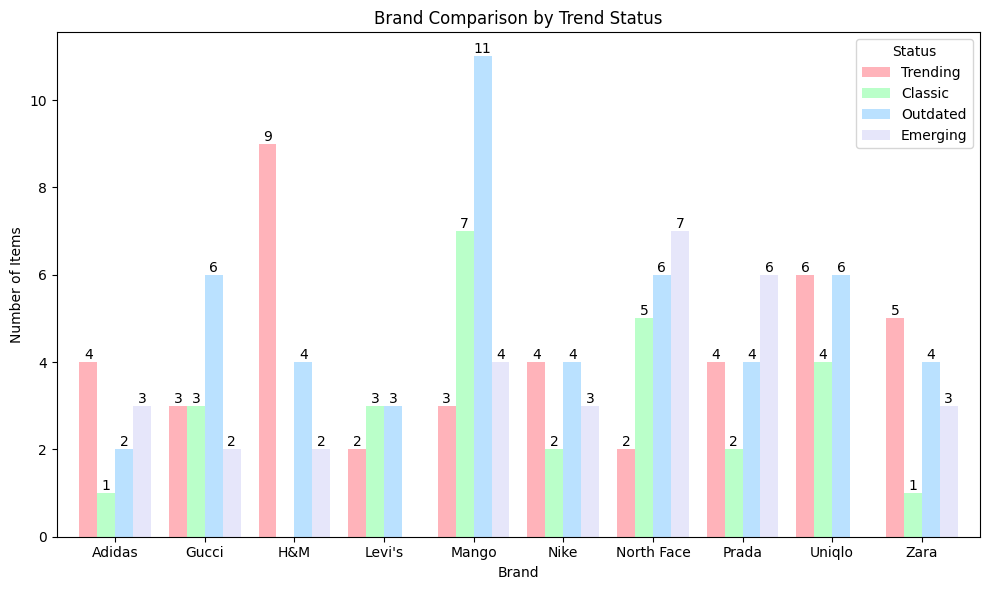

In [4]:
target_statuses = ['Trending', 'Classic', 'Outdated', 'Emerging']
filtered_df = df[df['Trend_Status'].isin(target_statuses)]


comparison_data = filtered_df.groupby(['Brand', 'Trend_Status']).size().unstack(fill_value=0)
comparison_data = comparison_data.reindex(columns=target_statuses, fill_value=0)

pastel_colors = ['#FFB3BA', '#BAFFC9', '#BAE1FF', '#E6E6FA']

ax = comparison_data.plot(kind='bar', color=pastel_colors, figsize=(10, 6), width=0.8)

plt.title('Brand Comparison by Trend Status')
plt.ylabel('Number of Items')
plt.xlabel('Brand')
plt.xticks(rotation=0)
plt.legend(title='Status')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(str(int(p.get_height())), 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()

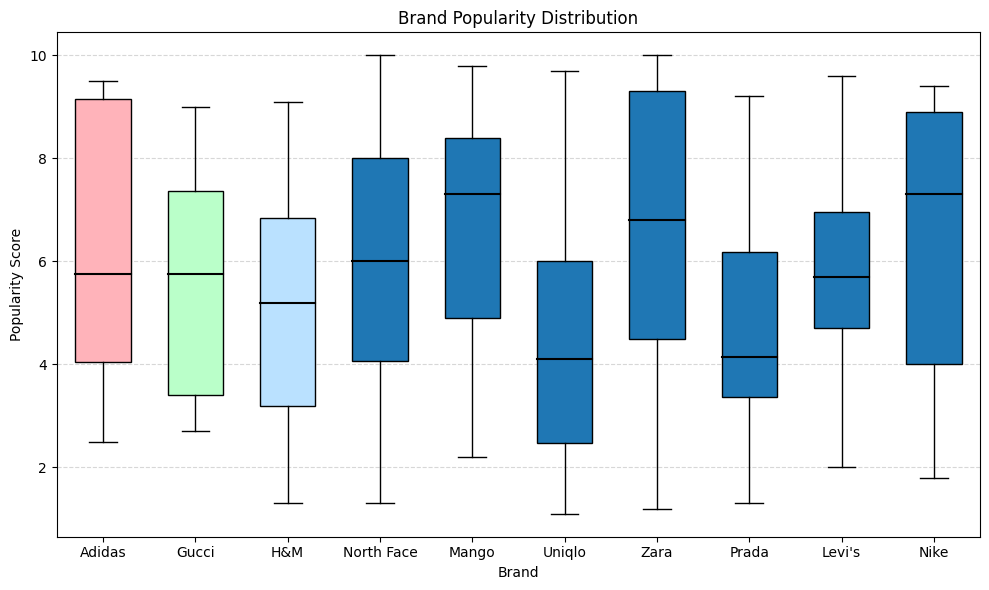

In [5]:
brands = df['Brand'].unique()

plt.figure(figsize=(10, 6))

plot_data = [df[df['Brand'] == b]['Popularity_Score'] for b in brands]
bp = plt.boxplot(plot_data, labels=brands, patch_artist=True, widths=0.6)

colors = ['#FFB3BA', '#BAFFC9', '#BAE1FF'] # Pastel Red, Green, Blue
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.setp(bp['medians'], color='black', linewidth=1.5)
plt.title('Brand Popularity Distribution')
plt.ylabel('Popularity Score')
plt.xlabel('Brand')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('brand_popularity_boxplot.png')

In [6]:
df['Color'].unique()

array(['Brown', 'Red', 'Blue', 'Black', 'Gray', 'Cream', 'Maroon',
       'Green', 'Beige', 'White'], dtype=object)

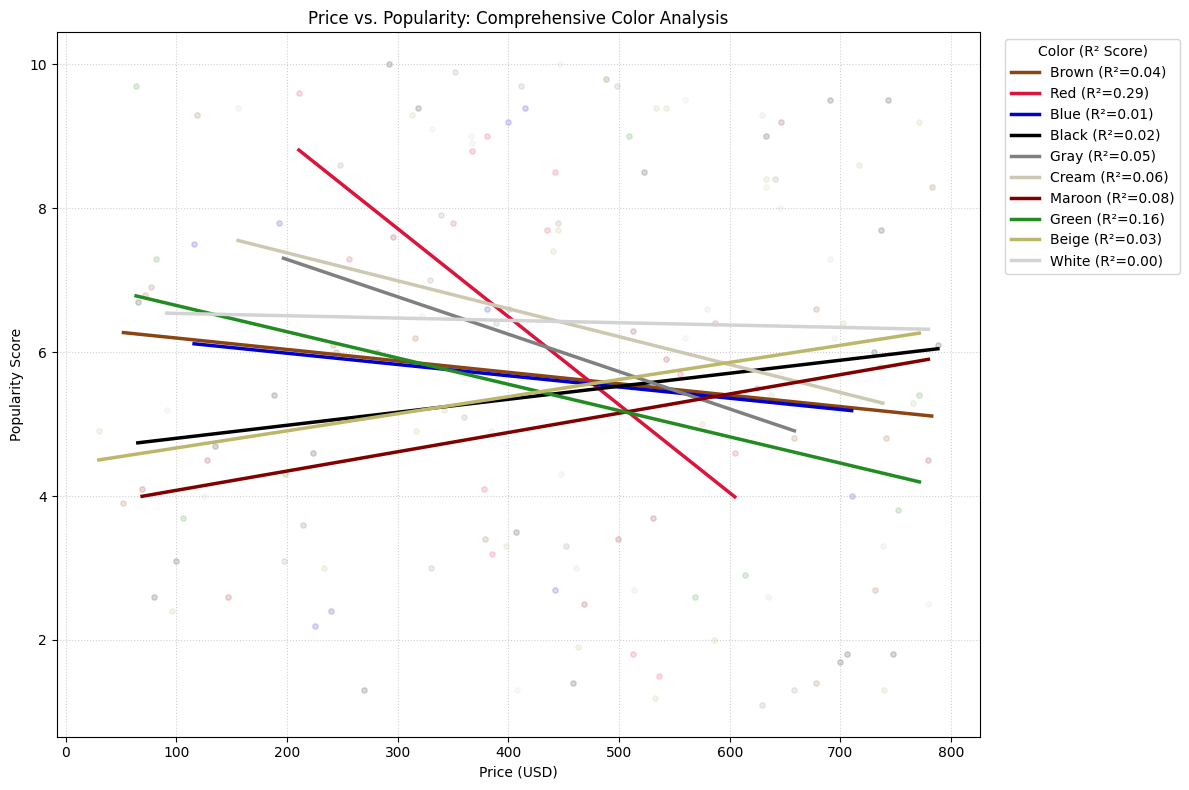

In [7]:
from sklearn.linear_model import LinearRegression


target_colors = ['Brown', 'Red', 'Blue', 'Black', 'Gray', 
                 'Cream', 'Maroon', 'Green', 'Beige', 'White']

plt.figure(figsize=(12, 8))


color_map = {
    'Brown': '#8B4513',
    'Red':   '#DC143C',
    'Blue':  '#0000CD',
    'Black': '#000000',
    'Gray':  '#808080',
    'Cream': '#CDC8B1', 
    'Maroon':'#800000',  
    'Green': '#228B22',   
    'Beige': '#BDB76B',   
    'White': '#D3D3D3'    
}


for color_name in target_colors:

    subset = df[df['Color'] == color_name].copy()
    

    if len(subset) > 1:
        X = subset['Price(USD)'].values.reshape(-1, 1)
        y = subset['Popularity_Score'].values
        
        reg = LinearRegression()
        reg.fit(X, y)
        

        c_hex = color_map.get(color_name, 'gray')
        plt.scatter(X, y, color=c_hex, alpha=0.15, s=15)
        
        line_x = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
        line_y = reg.predict(line_x)
        
        label_txt = f"{color_name} (R²={reg.score(X, y):.2f})"
        plt.plot(line_x, line_y, color=c_hex, linewidth=2.5, label=label_txt)

plt.title('Price vs. Popularity: Comprehensive Color Analysis')
plt.xlabel('Price (USD)')
plt.ylabel('Popularity Score')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Color (R² Score)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()